# Iran war risk and global financial markets in 2026

**Panagiotis Housos · ph2606**  
FRE-GY 7871A · NLP and the Investment Process · Assignment 3  
Main window: **28 February–18 September 2026**. Prepared 21 September 2026.  
This notebook contains saved outputs. Follow the README to acquire the local inputs before executing it.

## 1. Research question and principal finding

How does unusually intensive Iran-war reporting change the covariance structure of global financial markets? The main sample starts with the outbreak on **28 February 2026** and ends on **18 September**, the latest completed US cash-market session when inputs were frozen before September 21 trading. February 27 closes supply the prewar baseline; March 2 supplies the first post-outbreak return. January–February information provides context and the broad social appendix, not observations in the primary financial estimates.

The study first implements the uncentered second-moment and instrumental-variable method in Rigobon and Sack’s *The Effects of War Risk on U.S. Financial Markets*. **NLP determines high-news (1) and low-news (0) days; market data determine responses. Story direction is unnecessary for this identification.** Tables 1–3 retain the paper’s purposes: a high-news chronology, three IV sensitivity estimates and conditional variance calculations.

Relevant publisher coverage above its active-window 75th percentile identifies **35 high-news and 105 low-news sessions**. Fitted Treasury availability and interval alignment leave **34 H/L pairs**. Anchor variance rises, but a positive shift alone does not establish an isolated war shock. The rank-one restriction fits poorly, some identifying moments disagree and results depend on source, threshold and timing.

From the prewar close, WTI spot rises **59.83%** and Brent **83.40%** through September 15, while the spot spread widens from **$4.36 to $23.78 per barrel**. Ten-year CMT yields rise 97 basis points through September 17. These are observed trends, not causal war effects. The report distinguishes the Iraq benchmark, Iran hypotheses and actual estimates—including failures to match expected signs. Directional news, novel language and the 404-record Truth Social corpus are separate extensions.

In [1]:
from pathlib import Path
import sys,json,hashlib
import numpy as np
import pandas as pd
from IPython.display import display,Image
ROOT=Path.cwd()
assert (ROOT/'src').is_dir(), 'Execute from the repository root.'
sys.path.insert(0,str(ROOT))
OUT=ROOT/'outputs'
pd.set_option('display.max_rows',60)
pd.set_option('display.max_columns',18)
pd.options.display.float_format='{:,.4f}'.format
from src.text_features import build as build_text
from src.social_audit import main as audit_social
from src.social_timing import build as build_social_timing
from src.duration_news import build as build_duration
from src.news_regimes import build as build_news_regimes
from src.phrase_audit import build as build_phrase_audit
from src.iran_study import run
from src.study_figures import build as build_figures
build_text()
audit_social()
social_audit,social_calendar,social_sessions,social_summary=build_social_timing()
headlines,gdelt_sources,duration_daily,duration_summary=build_duration()
regimes,high_news_calendar,regime_summary=build_news_regimes()
phrase_documents,phrase_terms,phrase_examples,phrase_summary=build_phrase_audit()
diagnostics=run(bootstrap=1999)
build_figures()
for name,digest in diagnostics['input_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest()==digest,name
t1=pd.read_csv(OUT/'paper_table1.csv')
t2=pd.read_csv(OUT/'paper_table2.csv')
t3=pd.read_csv(OUT/'paper_table3.csv')
print('Analysis recomputed from cached inputs; hashes verified.')

{
  "eligible_news_documents": 1035,
  "within_cutoff_documents": 1035,
  "war_relevant_documents": 926,
  "numeric_text_eligible": 219,
  "modified_after_cutoff": 0,
  "mapped_effective_date": 1035,
  "scoring_target": "Unquoted physical conflict/economic context after paragraph-level official-subject, policy and attribution exclusions, plus sentence-level personal-anaphora exclusions. Attention counts independently retain all relevant articles.",
  "limits": "Conservative heuristic exclusions can omit factual reporting and cannot guarantee semantic separation; no independent labeled accuracy; financial LM vocabulary transferred to news; current revised text. Absence of eligible text yields a missing value, not neutrality.",
  "idf": "Full eligible news corpus, retrospective; no prediction claim."
}


{
  "candidate_rows_audited": 404,
  "candidate_ids_match_independent_raw_retrieval": true,
  "all_text_and_local_dates_match_raw_snapshot": true,
  "candidate_csv_sha256": "4611dc7fbb7ff4310a4e99dcb2836c1a66cdc85399baab97daad80ae0eae77eb",
  "archive_sha256": "1aa10768c1436324641a033134801ef495c0b6d12e94520afa7da42a4d2db31d",
  "source_form_counts": {
    "Text without URL or explicit attribution prefix": 258,
    "Text plus URL": 96,
    "Explicit RT marker": 43,
    "Explicit attribution prefix": 4,
    "URL only": 3
  },
  "relevance_match_location_counts": {
    "Body": 327,
    "Body and URL": 66,
    "URL only": 11
  },
  "explicit_repost_marker_records": 43,
  "explicit_self_repost_prefix_records": 31,
  "explicit_attribution_prefix_records": 4,
  "url_only_records": 3,
  "records_with_urls": 110,
  "records_with_unreviewed_media": 17,
  "empty_text_records_with_media_in_full_2026_window": 1908,
  "candidate_records_with_identical_text_other_id": 26,
  "unique_candidate_texts":

{
  "candidate_records": 404,
  "equity_state_counts": {
    "open": 128,
    "weekend": 101,
    "pre_open": 82,
    "after_close": 82,
    "holiday": 11
  },
  "friday_to_sunday_posts": 162,
  "reaction_close_without_observed_price": 0,
  "claim_cue_record_counts": {
    "ceasefire_truce": 15,
    "negotiations_agreement": 111,
    "cessation_cancellation": 18,
    "continuation_extension": 33,
    "strikes_military": 162,
    "shipping_blockade": 122,
    "nuclear": 85,
    "energy_prices": 63,
    "trade_sanctions": 19,
    "humanitarian_civilian": 18
  }
}


{
  "distinct_source_documents": 1035,
  "legacy_retrieved_documents": 244,
  "expanded_retrieved_documents": 642,
  "newly_retrieved_distinct_documents": 398,
  "cue_document_counts": {
    "code_name_cue": 5,
    "ceasefire_extension_cue": 3,
    "war_extension_cue": 2,
    "deadline_extension_cue": 1,
    "ceasefire_collapse_or_expiry_cue": 4,
    "negated_end_review": 2,
    "negated_collapse_review": 0,
    "conditional_or_modal_cue": 105,
    "quotation_cue": 300,
    "labor_context_cue": 7,
    "trade_war_cue": 0,
    "scope_ambiguity_cue": 12
  },
  "synthetic_software_checks": 17
}


NLP main method: 34 H and 34 L sessions


{
  "start": "2026-02-28",
  "cutoff": "2026-09-18",
  "created_utc": "2026-09-22T00:32:16.659982+00:00",
  "main_regime": "Unsigned NLP high-intensity Guardian war coverage, full active-window strict upper-quartile threshold",
  "main_curve": "Federal Reserve GSW fitted off-the-run coupon-equivalent par yields",
  "curve_last_date": "2026-09-11",
  "event_records": 35,
  "event_sessions": 35,
  "main_pairs": 34,
  "low_news_sessions": 105,
  "equity_sessions": 140,
  "no_major_event_sessions": 121,
  "main_weak_rows": 2,
  "main_available_outcomes": 19,
  "rank_one_residual": 0.6023388123547941,
  "lp_primary_tests": 48,
  "lp_primary_q_lt05": 0,
  "lp_placebo_q_lt05": 3,
  "lp_min_primary_q": 0.28494143360357227,
  "nlp_regimes": {
    "start": "2026-02-28",
    "end": "2026-09-18",
    "first_session": "2026-03-02",
    "last_session": "2026-09-18",
    "sessions": 140,
    "high_sessions": 35,
    "low_sessions": 105,
    "missing_coverage_sessions": 0,
    "missing_coverage_dates"

Analysis recomputed from cached inputs; hashes verified.


## 2. Data, observation windows and free news access

The references are [Rigobon and Sack (2003), NBER Working Paper 9609](https://www.nber.org/papers/w9609) and [Rigobon (2003), Review of Economics and Statistics 85(4), 777–792](https://doi.org/10.1162/003465303772815727). The war paper selected 17 news days within 47 business days before Iraq’s invasion, including some other security developments. Here Tables 1–3 use the active Iran-conflict window.

All 18 market feeds were refreshed. Exchange-traded series and breakeven inflation reach September 18; CMT yields and credit OAS September 17; spot oil September 15; the broad dollar and fitted off-the-run curve September 11. Nothing is forward-filled. Prices use simple percentage returns, $r_t=100(P_t/P_{t-1}-1)$; yields/OAS use percentage-point changes; dollar oil and the physical spread use dollars per barrel. Each one-session outcome must share current and preceding dates with the reference; incomplete H/L pairs are removed together.

The main Treasury inputs are Gürkaynak–Sack–Wright coupon-equivalent **par yields**, SVENPY02 and SVENPY10. The Fed model excludes on-the-run and first-off-the-run notes and bonds, giving a closer conceptual match to the paper than CMT yields, while remaining a revisable research estimate. [Fed curve documentation](https://www.federalreserve.gov/data/nominal-yield-curve.htm). The original 12-month oil contract, dollar gold and traded liquidity premium are not identically reproduced. Nearby WTI, GLD returns and OAS are disclosed proxies; unavailable premium cells stay blank.

**GDELT is the free historical connector for the broad-source comparison.** All 261 daily bulk files for January 1–September 18 were obtained. The broad Iran actor/location extract has 1,814,920 event rows and 372,908 canonical URLs. These are NLP event metadata and links, not downloaded full articles. Empirical counts further require an Iranian actor, a recent event and eligible CAMEO codes; 57,410 geography-only war-coded rows are excluded. An Iranian actor still does not prove this war is the subject. [GDELT access](https://www.gdeltproject.org/data.html); [event codebook](https://data.gdeltproject.org/documentation/GDELT-Data_Format_Codebook.pdf).

The **primary text regime** uses publisher text for explicit relevance and better timestamps. The Guardian archive has 1,896 URLs: 444 live/multimedia and 417 non-news exclusions leave 1,035 documents, with no unresolved download failures. NLP identifies 926 relevant January-context articles; **869 map to active-conflict return windows**. Relevance requires Iran and conflict/energy context in a headline or at least two body sentences. This is one English-language outlet and a heuristic classifier, not a global census or independently validated label set.

GDELT’s keyless DOC API supports discovery but hit caps/rate limits; bulk files were practical. The Guardian academic/noncommercial API needs a key and permits 500 requests/day; pages here were collected directly. NewsAPI’s free developer tier has 100 requests/day, a 24-hour delay and one month of history. [Guardian terms](https://open-platform.theguardian.com/access/); [NewsAPI plans](https://newsapi.org/pricing).

In [2]:
market_manifest=json.loads((ROOT/'data/raw/market/manifest.json').read_text())
display(pd.DataFrame(market_manifest['series'])[['series','provider','first','last','observations_2026']])
display(pd.read_csv(ROOT/'data/processed/offrun_yields.csv',index_col=0).tail())
print(json.dumps(duration_summary,indent=2))
print(json.dumps(regime_summary,indent=2))
coverage=pd.read_csv(OUT/'gdelt_bulk_coverage.csv')
assert len(coverage)==261 and coverage.status.astype(str).eq('200').all()

,series,provider,first,last,observations_2026
0,DCOILWTICO,FRED,2025-12-15,2026-09-15,176
1,DCOILBRENTEU,FRED,2025-12-15,2026-09-15,178
2,DGS2,FRED,2025-12-15,2026-09-17,179
3,DGS10,FRED,2025-12-15,2026-09-17,179
4,DGS3MO,FRED,2025-12-15,2026-09-17,179
5,T10YIE,FRED,2025-12-15,2026-09-18,180
6,BAMLC0A4CBBB,FRED,2025-12-15,2026-09-17,188
7,BAMLH0A0HYM2,FRED,2025-12-15,2026-09-17,188
8,DTWEXBGS,FRED,2025-12-15,2026-09-11,175
9,CL=F,Yahoo Finance,2025-12-15,2026-09-18,179


,SVENPY02,SVENPY10
Date,,
2026-09-07,NaN,NaN
2026-09-08,4.4044,4.8440
2026-09-09,4.4351,4.8571
2026-09-10,4.5736,4.9810
2026-09-11,4.6405,4.9922


{
  "guardian_items": 1035,
  "guardian_war_items": 926,
  "guardian_categories": {
    "Attributed statement/policy context": 587,
    "War context; duration unclear": 187,
    "Outside Iran-war scope": 109,
    "Continuing fighting/disruption language": 104,
    "Negotiation context without verified cessation": 28,
    "Cessation/reopening language": 16,
    "Mixed physical developments": 4
  },
  "gdelt_source_urls": 372908,
  "gdelt_categories": {
    "Other Iran-related code": 272298,
    "Fighting/violence code": 89990,
    "Cessation/truce/withdrawal code": 7727,
    "Mixed cessation and fighting codes": 2893
  },
  "news_sessions": 179,
  "sessions_with_any_gdelt_war_news": 179,
  "sessions_with_no_guardian_war_article": 20,
  "guardian_clock_states": {
    "pre_open": 292,
    "after_close": 269,
    "weekend": 250,
    "open": 205,
    "holiday": 19
  },
  "guardian_friday_sunday": 370,
  "gdelt_signal_scope": "Recent event, IRN actor, and cessation or fighting CAMEO code; ge

## 3. Oil prices, the spread and the yield curve

February 27 spot prices are $66.96 for WTI and $71.32 for Brent; their September 15 observations are $107.02 and $130.80. Define $S_t=P_t^{Brent}-P_t^{WTI}$ and $p_t=100(P_t^{Brent}/P_t^{WTI}-1)$. The spread rises by **$19.42 per barrel**, and the relative premium from **6.51% to 22.22% of WTI**. Geography, quality, inventories, transport and refining also affect it; this is not a pure war premium or probability.

Nearby rolling futures end September 18 at $100.30 and $103.87, gains of 49.66% and 43.31%. Their $3.57 difference is not the September 15 spot spread and may compare different delivery months. Nearby oil is also more exposed to immediate physical constraints than the paper’s year-ahead contract. A spread trade requires matched expiries and basis analysis. [EIA on physical prices and contract timing](https://www.eia.gov/todayinenergy/detail.php?id=67424).

The two-year CMT rises from 3.38% to 4.67%, and the ten-year from 3.97% to 4.94%, through September 17. The 10y-minus-2y curve falls from 59 to 27 basis points: **32 bp of bear flattening**. Yield changes are not bond returns. From the same baseline, S&P gains 11.22%, Nasdaq 17.00%, EFA 1.19% and EEM 7.67%; GLD falls 17.07%. ETFs are adjusted fund-price proxies; equity indexes are price indexes. Full-period movements include other shocks and differ from isolated war-news effects.

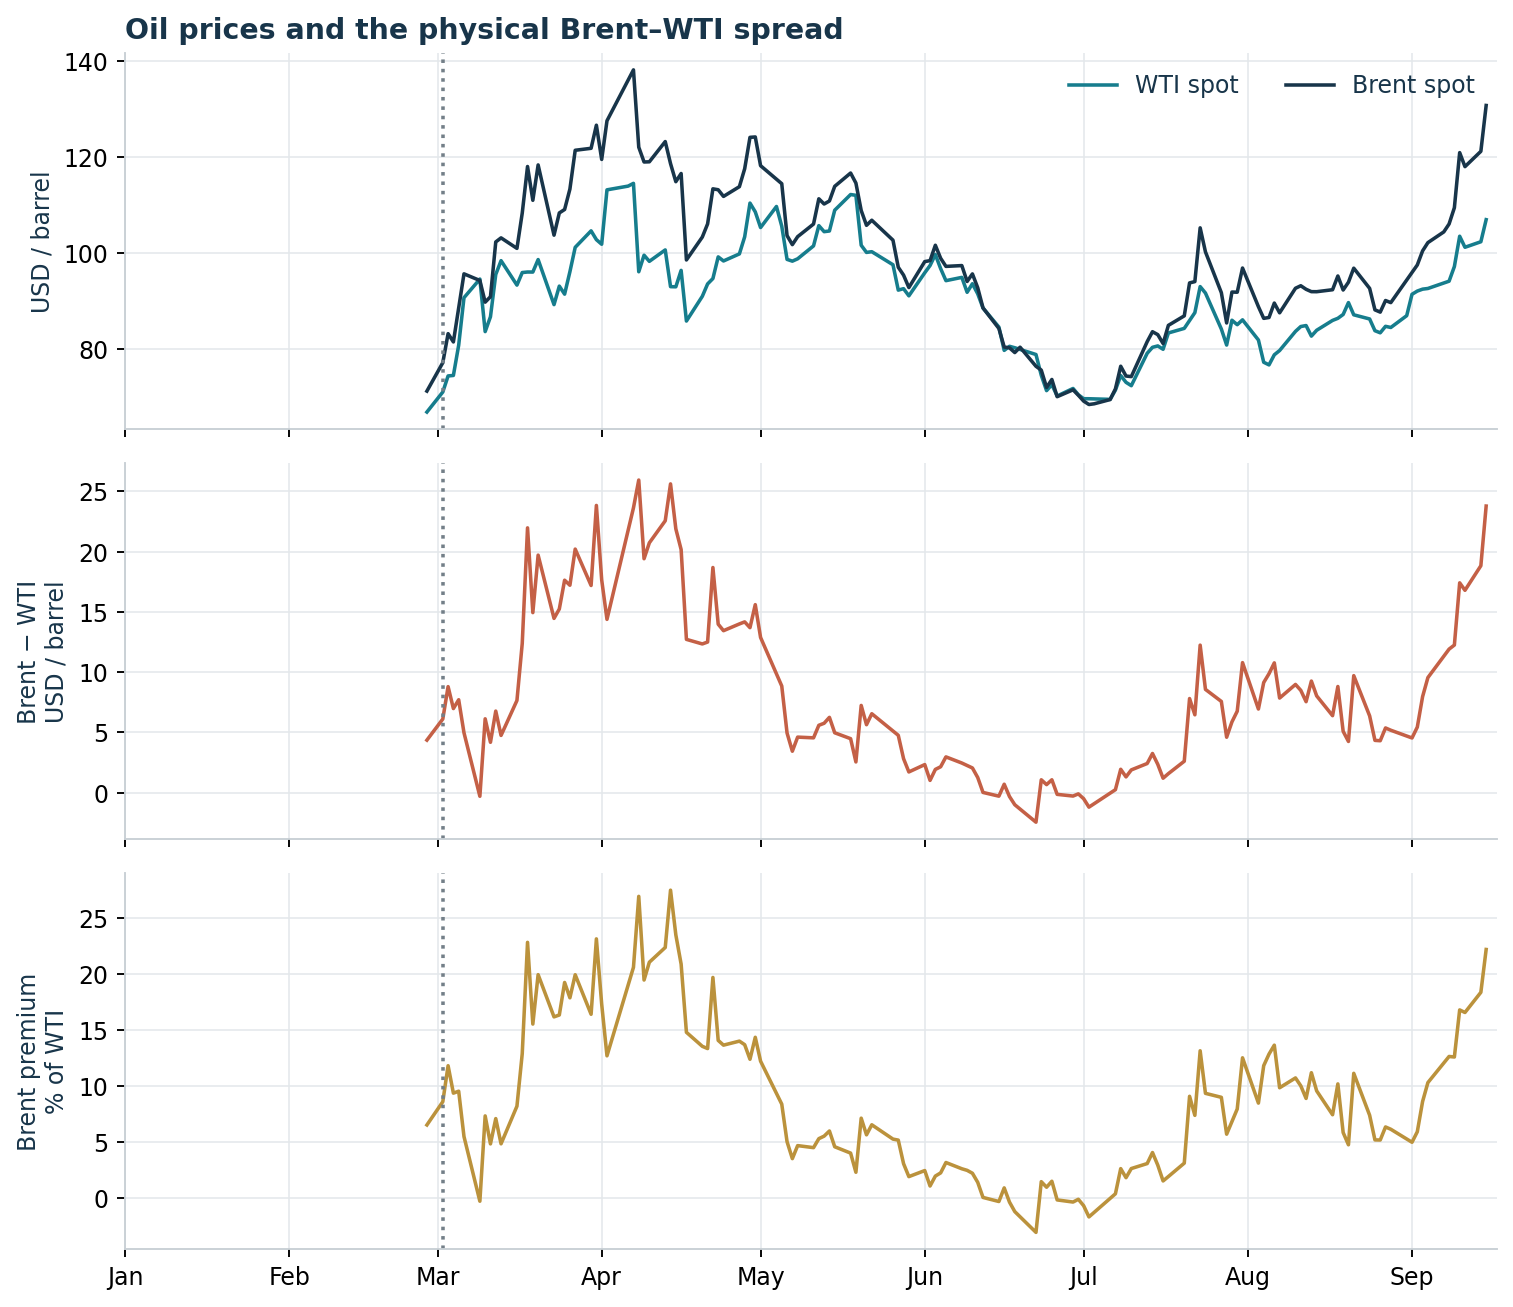

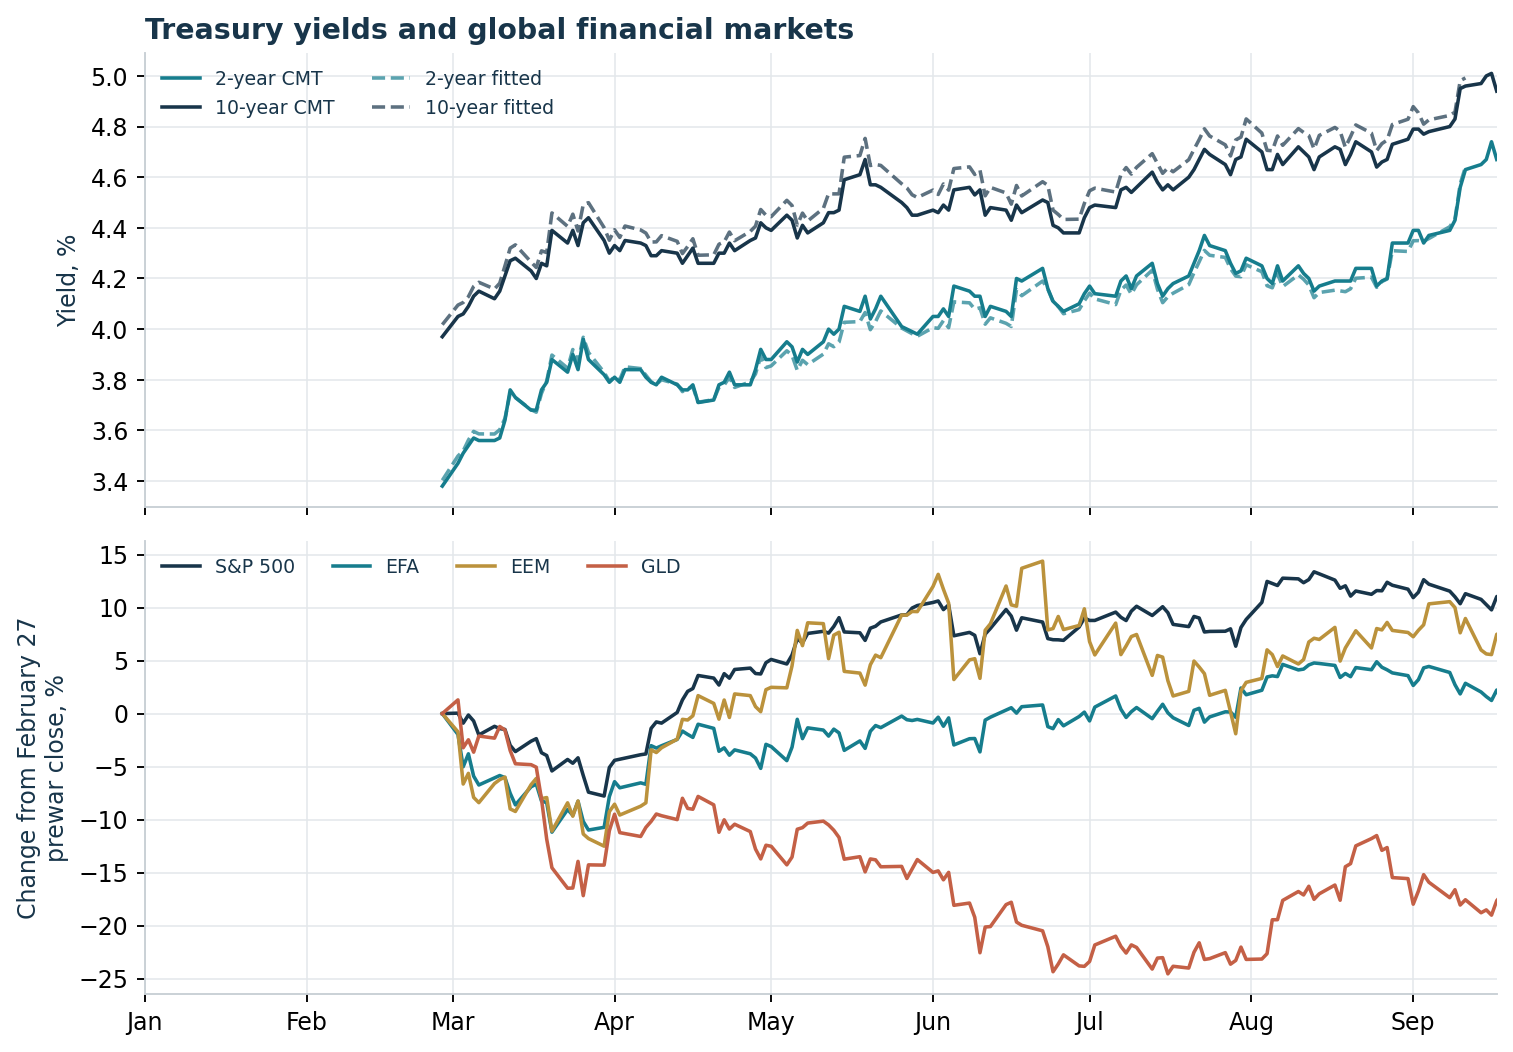

,Market,Baseline,Endpoint,Baseline level,Last level,Simple change %
0,wti_spot,2026-02-27,2026-09-15,66.9600,107.0200,59.8268
1,brent_spot,2026-02-27,2026-09-15,71.3200,130.8000,83.3988
2,wti_futures,2026-02-27,2026-09-18,67.0200,100.3000,49.6568
3,brent_futures,2026-02-27,2026-09-18,72.4800,103.8700,43.3085
4,sp500,2026-02-27,2026-09-18,"6,878.8799","7,650.5000",11.2172
5,nasdaq,2026-02-27,2026-09-18,"22,668.2109","26,522.5391",17.0032
6,efa,2026-02-27,2026-09-18,103.7384,104.9700,1.1872
7,eem,2026-02-27,2026-09-18,62.2564,67.0300,7.6676
8,gold_gld,2026-02-27,2026-09-18,483.7500,401.1700,-17.0708


In [3]:
display(Image(filename=str(OUT/'study_oil.png')))
display(Image(filename=str(OUT/'study_markets.png')))
from src.iran_study import market_panel
_,market_values,market_levels=market_panel('cmt')
rows=[]
for name in ['wti_spot','brent_spot','wti_futures','brent_futures','sp500','nasdaq','efa','eem','gold_gld']:
    x=market_values[name].loc['2026-02-27':'2026-09-18'].dropna()
    rows.append([name,str(x.index[0].date()),str(x.index[-1].date()),x.iloc[0],x.iloc[-1],100*(x.iloc[-1]/x.iloc[0]-1)])
display(pd.DataFrame(rows,columns=['Market','Baseline','Endpoint','Baseline level','Last level','Simple change %']))

## 4. NLP high-news days and original-paper identification

Let $N_t$ be distinct relevant publisher articles in a close-to-close information window and $D_t$ its elapsed hours divided by 24. The effective clock is the later of publication and modification, which handles known edits conservatively without reconstructing original real-time bodies. The first news window starts at February 28 midnight ET; its return uses Friday’s close. Set $A_t=N_t/D_t$ and $H_t=1$ when $A_t>Q_{0.75}(A)$, otherwise 0. The threshold is **5.25 articles per elapsed day**; ties stay low. This retrospective rule is not a forecast or preregistered threshold and is not tuned against returns.

There are **35 high and 105 low sessions** among 140 active-conflict sessions. Match each estimable H without replacement to the nearest eligible L by calendar distance, preferring the earlier date on a tie. Fitted-curve data supply **34 pairs**. The longest gap is 38 days, weakening the unchanged-nuisance-volatility assumption; within-month thresholds test sensitivity. Low means lower retrieved coverage, not fundamentals-only trading. Only four sessions have no relevant publisher article. Failed coverage would be missing rather than zero.

Write $\Delta X_t=d w_t+u_t$, normalizing the two-year loading to one. With one changing orthogonal war-shock variance, stable loadings and unchanged nuisance moments,

$$\Omega_H-\Omega_L=\delta dd',\qquad\delta>0.$$

Identification comes from this covariance shift and **does not require story direction**. Robust OLS errors do not provide identification. Following the paper, use zero-mean, uncentered moments and no intercept. For two-year change $x$ and outcome $y$, define $a=E_H[x^2]-E_L[x^2]$, $b=E_H[xy]-E_L[xy]$ and $c=E_H[y^2]-E_L[y^2]$. Then $\widehat d_1=b/a$ and $\widehat d_2=c/b$. Instruments are $s_tx_t$ and $s_ty_t$, with $s_t=+1$ on H and −1 on L; pooled 2SLS uses both.

**Table 1 is the NLP high-news chronology.** It shows session, article count/intensity, comparison date and the earliest effective-clock relevant headline as an illustrative source. That headline alone does not define H. Full article/session audits remain local. The manually sourced event calendar is a separate robustness and weekend-timing check.

,market_date,war_articles,intensity,friday_sunday_articles,description,source_url,included_in_main_estimation
0,2026-03-02,62,23.2500,49,War on Iran: how the US-Israeli bid for regime...,https://www.theguardian.com/us-news/2026/feb/2...,True
1,2026-03-03,21,21.0000,0,Protesters rally across US after strikes on Ir...,https://www.theguardian.com/us-news/2026/feb/2...,True
2,2026-03-04,20,20.0000,0,US and Israel offer shifting justifications f...,https://www.theguardian.com/world/2026/mar/03/...,True
3,2026-03-05,15,15.0000,0,Britain not ruling out future strikes on Iran ...,https://www.theguardian.com/world/2026/mar/04/...,True
4,2026-03-06,18,18.0000,8,US troops were told war on Iran was ‘all part ...,https://www.theguardian.com/world/2026/mar/03/...,True
5,2026-03-09,24,8.1127,9,Pakistani man convicted of plotting to kill Tr...,https://www.theguardian.com/us-news/2026/mar/0...,True
6,2026-03-10,13,13.0000,0,Von der Leyen calls for EU foreign policy to b...,https://www.theguardian.com/world/2026/mar/09/...,True
7,2026-03-11,18,18.0000,0,Trump news at a glance: president issues an ul...,https://www.theguardian.com/us-news/2026/mar/0...,True
8,2026-03-12,15,15.0000,0,Elevating injured Mojtaba Khamenei to supreme ...,https://www.theguardian.com/world/2026/mar/11/...,True
9,2026-03-13,9,9.0000,4,Middle East war creating ‘largest supply disru...,https://www.theguardian.com/business/2026/mar/...,True


,high_date,low_date,status,distance_days
0,2026-03-02,2026-03-23,Matched,21.0000
1,2026-03-03,2026-03-25,Matched,22.0000
2,2026-03-04,2026-03-27,Matched,23.0000
3,2026-03-05,2026-03-31,Matched,26.0000
4,2026-03-06,2026-04-10,Matched,35.0000
5,2026-03-09,2026-04-13,Matched,35.0000
6,2026-03-10,2026-04-14,Matched,35.0000
7,2026-03-11,2026-04-15,Matched,35.0000
8,2026-03-12,2026-04-16,Matched,35.0000
9,2026-03-13,2026-04-17,Matched,35.0000


,month,sessions,high,war_articles,mean_intensity
0,2026-03,22,18.0000,371,11.7135
1,2026-04,21,7.0000,158,5.7143
2,2026-05,20,3.0000,82,3.0083
3,2026-06,21,5.0000,107,3.7817
4,2026-07,22,1.0000,79,2.8106
5,2026-08,21,1.0000,39,1.2540
6,2026-09,13,0.0000,33,1.9872


,war_articles,interval_days,intensity
count,140.0000,140.0000,140.0000
mean,6.2071,1.4473,4.5091
std,8.3066,0.8960,4.6995
min,0.0000,1.0000,0.0000
25%,2.0000,1.0000,1.6667
50%,4.0000,1.0000,3.0000
75%,7.0000,1.0000,5.2500
max,62.0000,4.0000,23.2500


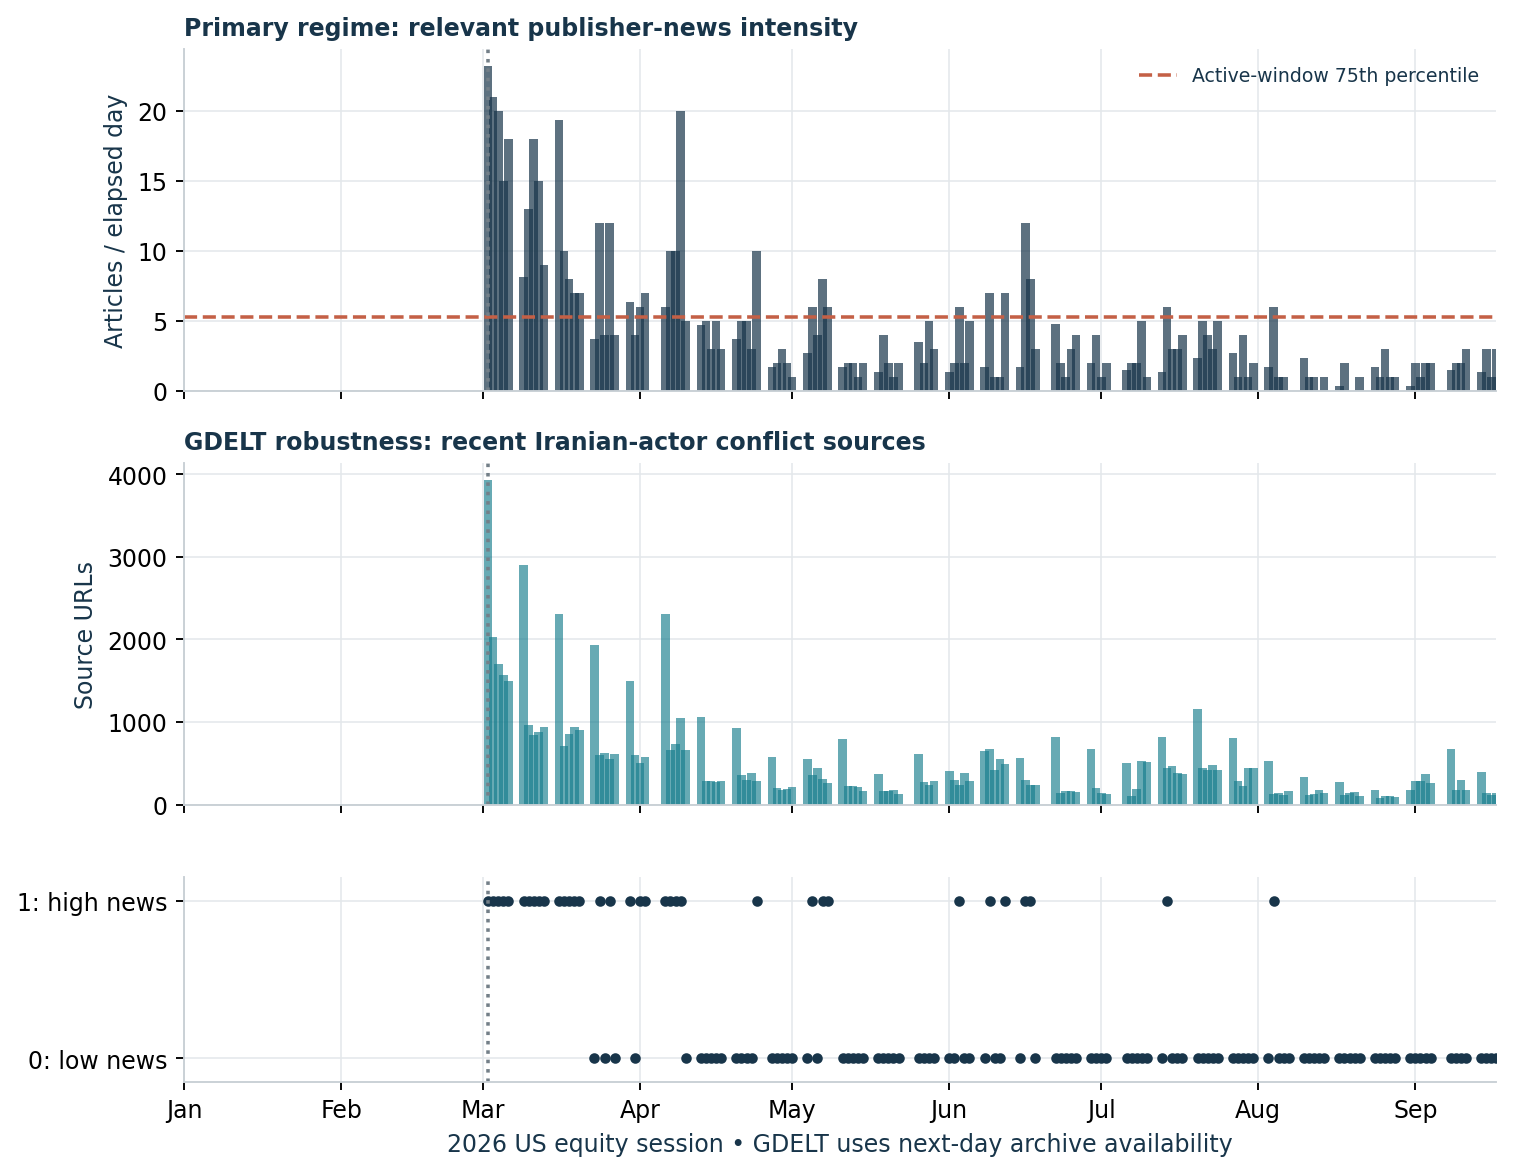

In [4]:
display(t1[['market_date','war_articles','intensity','friday_sunday_articles','description','source_url','included_in_main_estimation']])
display(pd.read_csv(OUT/'paper_matching.csv'))
display(pd.read_csv(OUT/'nlp_regimes_monthly.csv'))
display(regimes[['war_articles','interval_days','intensity']].describe())
display(Image(filename=str(OUT/'study_news.png')))

## 5. Table 2: three IV sensitivity estimates

Each effect is $-0.25\widehat d$, the paper’s **25-bp two-year-yield decline**. Inputs are percentage-point changes, so the multiplier is −0.25. This fixes units without establishing which factor orientation means greater Iran-war risk.

Parentheses show absolute HC1 IV t-statistics with no-intercept finite-sample correction. The paper does not specify its covariance estimator sufficiently to reproduce that convention exactly; classical t-statistics remain in the notebook. Bootstrap diagnostics use 1,999 independent within-H/L resamples, fixed seeds and common draws for identical anchor samples. They are supplementary, not a source-paper recipe or weak-IV-robust confidence sets.

**2 of 19 available rows** have a reference-variance interval crossing zero and are marked W; unreliable ratio intervals are withheld. Other rows still require valid instruments and stable restrictions. Pooled responses are **−0.162 pp for the ten-year yield, +1.99% for S&P, +13.67% for WTI spot and −2.94% for Brent spot**. Opposing oil signs and disagreement among moments challenge a common one-factor interpretation. Conventional significance cannot repair invalid exclusions or unstable transmission.

In [5]:
display(t2[['label','unit','n_high','omega1_effect','omega1_abs_t_hc1','omega2_effect','omega2_abs_t_hc1','pooled_effect','pooled_abs_t_hc1','weak_reference_variance_shift']])
display(t2[['label','pooled_abs_t_classical','pooled_abs_t_hc1','pooled_effect_ci_low','pooled_effect_ci_high','availability_reason']])
display(pd.read_csv(OUT/'paper_diagnostics.csv'))

,label,unit,n_high,omega1_effect,omega1_abs_t_hc1,omega2_effect,omega2_abs_t_hc1,pooled_effect,pooled_abs_t_hc1,weak_reference_variance_shift
0,10-year fitted Treasury,pp,34,-0.1530,1.9313,-0.1380,0.6739,-0.1621,4.0557,False
1,10-year breakeven,pp,34,0.0470,0.6958,0.0077,0.0434,0.0378,1.2877,False
2,10-year liquidity premium,pp,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S&P 500,%,34,1.4657,0.8909,-3.5586,0.2229,1.9880,1.2734,False
4,BBB OAS,pp,33,0.0051,0.1518,1.3919,0.1479,-0.0013,0.0382,True
5,High-yield OAS,pp,33,0.0771,0.5858,0.7778,0.4515,0.1084,0.7737,True
6,WTI nearby futures,$/bbl,34,5.7247,0.4887,82.2419,0.4103,14.5925,1.0984,False
7,Gold ETF (GLD),%,34,-0.2057,0.0459,37.6351,0.0611,0.3123,0.1155,False
8,Broad dollar,%,34,-0.3080,0.5537,-9.5850,0.5118,0.0155,0.0247,False
9,WTI spot,%,34,3.5094,0.3025,154.6449,0.2868,13.6735,1.0632,False


,label,pooled_abs_t_classical,pooled_abs_t_hc1,pooled_effect_ci_low,pooled_effect_ci_high,availability_reason
0,10-year fitted Treasury,3.6820,4.0557,-0.3332,-0.0874,NaN
1,10-year breakeven,1.0579,1.2877,-0.0380,0.1179,NaN
2,10-year liquidity premium,NaN,NaN,NaN,NaN,A traded current-issue yield and matching off-...
3,S&P 500,1.2959,1.2734,-1.3583,6.5134,NaN
4,BBB OAS,0.0432,0.0382,NaN,NaN,NaN
5,High-yield OAS,0.7691,0.7737,NaN,NaN,NaN
6,WTI nearby futures,1.3756,1.0984,-8.1584,62.9295,NaN
7,Gold ETF (GLD),0.1180,0.1155,-5.7358,6.4481,NaN
8,Broad dollar,0.0239,0.0247,-3.1453,4.5703,NaN
9,WTI spot,1.2330,1.0632,-12.6038,62.0974,NaN


,reference,outcome,n_high,n_low,n_estimation,n_rows_dropped,n_pairs_dropped,delta_xx,delta_xy,...,omega1_ci_low,omega1_ci_high,omega2_interval_suppressed,omega2_ci_low,omega2_ci_high,pooled_interval_suppressed,pooled_ci_low,pooled_ci_high,diagnostic_interpretation
0,two_year,ten_year,34,34,68,0,0,0.0015,0.0009,...,-1.1670,1.4111,True,NaN,NaN,False,0.3495,1.3329,Variance-shift and rank diagnostics do not est...
1,two_year,breakeven_10y,34,34,68,0,0,0.0015,-0.0003,...,-1.8996,0.2194,True,NaN,NaN,False,-0.4718,0.1518,Variance-shift and rank diagnostics do not est...
2,two_year,sp500,34,34,68,0,0,0.0015,-0.0089,...,-26.6158,25.6029,True,NaN,NaN,False,-26.0537,5.4331,Variance-shift and rank diagnostics do not est...
3,two_year,bbb_spread,33,33,66,2,1,0.0014,-0.0000,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
4,two_year,hy_spread,33,33,66,2,1,0.0014,-0.0004,...,NaN,NaN,True,NaN,NaN,True,NaN,NaN,Variance-shift and rank diagnostics do not est...
5,two_year,wti_dollar,34,34,68,0,0,0.0015,-0.0348,...,-315.0987,56.4344,True,NaN,NaN,False,-251.7178,32.6335,Variance-shift and rank diagnostics do not est...
6,two_year,gold_gld,34,34,68,0,0,0.0015,0.0013,...,-26.4093,107.7569,True,NaN,NaN,False,-25.7922,22.9431,Variance-shift and rank diagnostics do not est...
7,two_year,broad_dollar,34,34,68,0,0,0.0015,0.0019,...,-9.1458,9.9626,True,NaN,NaN,False,-18.2812,12.5812,Variance-shift and rank diagnostics do not est...
8,two_year,wti_spot,34,34,68,0,0,0.0015,-0.0213,...,-289.1584,71.6617,True,NaN,NaN,False,-248.3898,50.4151,Variance-shift and rank diagnostics do not est...
9,two_year,brent_spot,31,31,62,6,3,0.0019,0.0291,...,-148.3906,99.8922,True,NaN,NaN,False,-59.8450,107.9138,Variance-shift and rank diagnostics do not est...


## 6. The Iraq benchmark and Iran expectations

The original pooled response to the −25-bp two-year scenario was ten-year yields **−26 bp**, breakevens **−11 bp**, 12-month oil **+$0.77/barrel**, BBB spreads **+5 bp**, high-yield spreads **+34 bp**, S&P **−3.76%**, and a statistically small gold-dollar response. These are historical estimates, not coefficients imposed on Iran.

For adverse Iranian supply disruption, plausible hypotheses are oil up, wider credit spreads and lower equities. **Treasury yields may rise** if inflation and financing pressures outweigh safe-asset demand; breakevens may also rise. Debt and weaker flight to quality are hypotheses, not isolated mechanisms in these regressions. Gold, currencies and the relative oil spread need not have universal signs.

The comparison shows a **+25-bp two-year scenario** for Iran beside the original results. It negates the same estimates; standard-error magnitudes and absolute t-statistics are unchanged, and variance shares are unchanged because they use squared loadings. The ten-year becomes +0.162 pp and S&P −1.99%, agreeing in sign with those hypotheses. WTI spot instead falls 13.67%, Brent rises 2.94%, and the high-yield spread narrows. These counterexamples remain visible: changing orientation cannot make every outcome agree.

Sign agreement is not statistical confirmation. Original gold is dollars per ounce versus GLD percent; original oil is year-ahead versus nearby dollars. Units and contracts are explicit. Covariance shifts alone do not identify the semantic sign of a latent shock or establish that it represents only war risk.

In [6]:
display(pd.read_csv(OUT/'benchmark_expectations.csv'))
rise=pd.read_csv(OUT/'iran_yield_rise_scenario.csv')
display(rise[['label','unit','pooled_effect','pooled_abs_t_hc1','weak_reference_variance_shift']])
for method in ['omega1','omega2','pooled']:
    assert np.allclose(rise[method+'_effect'],-t2[method+'_effect'],equal_nan=True)
    assert np.allclose(rise[method+'_abs_t_hc1'],t2[method+'_abs_t_hc1'],equal_nan=True)

,variable,label,unit_2026,original_2003_effect,iran_expected_sign,iran_plus25bp_scenario,point_sign_matches_hypothesis,weak_reference_variance_shift,original_unit_note
0,ten_year,10-year fitted Treasury,pp,-0.2600,1.0000,0.1621,True,False,"Original gold is dollars, here GLD percent; or..."
1,breakeven_10y,10-year breakeven,pp,-0.1100,1.0000,-0.0378,False,False,"Original gold is dollars, here GLD percent; or..."
2,liquidity,10-year liquidity premium,pp,-0.0100,NaN,NaN,NaN,NaN,"Original gold is dollars, here GLD percent; or..."
3,sp500,S&P 500,%,-3.7600,-1.0000,-1.9880,True,False,"Original gold is dollars, here GLD percent; or..."
4,bbb_spread,BBB OAS,pp,0.0500,1.0000,0.0013,True,True,"Original gold is dollars, here GLD percent; or..."
5,hy_spread,High-yield OAS,pp,0.3400,1.0000,-0.1084,False,True,"Original gold is dollars, here GLD percent; or..."
6,wti_dollar,WTI nearby futures,$/bbl,0.7700,1.0000,-14.5925,False,False,"Original gold is dollars, here GLD percent; or..."
7,gold_gld,Gold ETF (GLD),%,1.3000,NaN,-0.3123,NaN,False,"Original gold is dollars, here GLD percent; or..."
8,broad_dollar,Broad dollar,%,-0.4400,NaN,-0.0155,NaN,False,"Original gold is dollars, here GLD percent; or..."
9,wti_spot,WTI spot,%,NaN,1.0000,-13.6735,False,False,"Original gold is dollars, here GLD percent; or..."


,label,unit,pooled_effect,pooled_abs_t_hc1,weak_reference_variance_shift
0,10-year fitted Treasury,pp,0.1621,4.0557,False
1,10-year breakeven,pp,-0.0378,1.2877,False
2,10-year liquidity premium,pp,NaN,NaN,NaN
3,S&P 500,%,-1.9880,1.2734,False
4,BBB OAS,pp,0.0013,0.0382,True
5,High-yield OAS,pp,-0.1084,0.7737,True
6,WTI nearby futures,$/bbl,-14.5925,1.0984,False
7,Gold ETF (GLD),%,-0.3123,0.1155,False
8,Broad dollar,%,-0.0155,0.0247,False
9,WTI spot,%,-13.6735,1.0632,False


## 7. Table 3: conditional variance calculations

The incremental contribution is $q_j=\widehat d_{pool,j}^{\,2}a$. Its H share is $100q_j/E_H[y_j^2]$; the full aligned war-window share is $100n_Hq_j/\sum_{t\in all}y_{jt}^2$. The denominator uses **all aligned days**, not just selected controls. Moments/contributions have squared outcome units; shares are percentages. Attribution cells for the reference yield and unavailable premium remain blank.

Stable nuisance moments, one changing orthogonal war factor and serial independence give the incremental variance a conditional lower-bound interpretation. Positive a does not establish those restrictions. These are **conditional diagnostics, not proven causal shares**; negative or above-100% estimates would remain visible.

The two-year H mean square is about 1.97 times L. Its increase is 0.001519 pp², with a bootstrap interval near [0.000082, 0.003186] pp² for the complete 34-pair sample: positive but close to zero at the lower endpoint. Ten-year H/full-window shares are **21.18%/6.67%**, versus 84.7%/62.8% in 2003. S&P shares are **10.54%/3.23%**, versus 34.2%/19.7%. Its H mean square is below L despite a positive model-implied contribution, cautioning against literal one-factor attribution.

In [7]:
display(t3[['label','unit_squared','n_high','variance_low','variance_high','predicted_variance_change','high_variance_share_pct','all_variance_share_pct','full_period_n','full_period_n_high']])

,label,unit_squared,n_high,variance_low,variance_high,predicted_variance_change,high_variance_share_pct,all_variance_share_pct,full_period_n,full_period_n_high
0,2-year fitted Treasury,(pp)^2,34.0000,0.0016,0.0031,NaN,NaN,NaN,NaN,NaN
1,10-year fitted Treasury,(pp)^2,34.0000,0.0025,0.0030,0.0006,21.1796,6.6704,134.0000,34.0000
2,10-year breakeven,(pp)^2,34.0000,0.0005,0.0005,0.0000,6.7989,1.7843,134.0000,34.0000
3,10-year liquidity premium,(pp)^2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,S&P 500,(%)^2,34.0000,1.0385,0.9117,0.0961,10.5397,3.2274,134.0000,34.0000
5,BBB OAS,(pp)^2,33.0000,0.0001,0.0003,0.0000,0.0136,0.0073,128.0000,33.0000
6,High-yield OAS,(pp)^2,33.0000,0.0035,0.0048,0.0003,5.3204,2.5188,128.0000,33.0000
7,WTI nearby futures,($/bbl)^2,34.0000,19.8968,31.3430,5.1770,16.5172,7.8677,134.0000,34.0000
8,Gold ETF (GLD),(%)^2,34.0000,3.2703,3.0821,0.0024,0.0769,0.0206,134.0000,34.0000
9,Broad dollar,(%)^2,34.0000,0.0787,0.1505,0.0000,0.0039,0.0017,134.0000,34.0000


## 8. Identification diagnostics and robustness

The six-market standardized second-moment contrast has multiple positive and negative eigenvalues. Its distance from the nearest positive rank-one matrix is **0.602 of its Frobenius norm**, a diagnostic rather than a formal rank-test p-value. Positive anchor variance and a significant ten-year t-statistic do not validate the whole system.

Checks use CMT yields; the curated chronology in the same war window; two-thirds/80th-percentile NLP thresholds; within-month thresholds; next-session timing; controls excluding adjacent high days; stricter GDELT Iran-actor counts; and pairs excluding scheduled FOMC dates. No return magnitudes select labels. GDELT and publisher intensity share 26 high sessions but differ in coverage and clocks.

The ten-year response is comparatively stable under several threshold choices, while equity/oil estimates vary materially. Next-session alignment produces large unstable oil ratios; within-month classification changes the S&P sign. Gaps up to 38 days cannot ensure unchanged non-war volatility. These findings motivate alternative designs rather than relying on the strongest individual t-statistic.

Eigenvalues: [ 1.131   0.7228  0.1573  0.1079 -0.1802 -0.3702] Relative residual: 0.6023388123547941


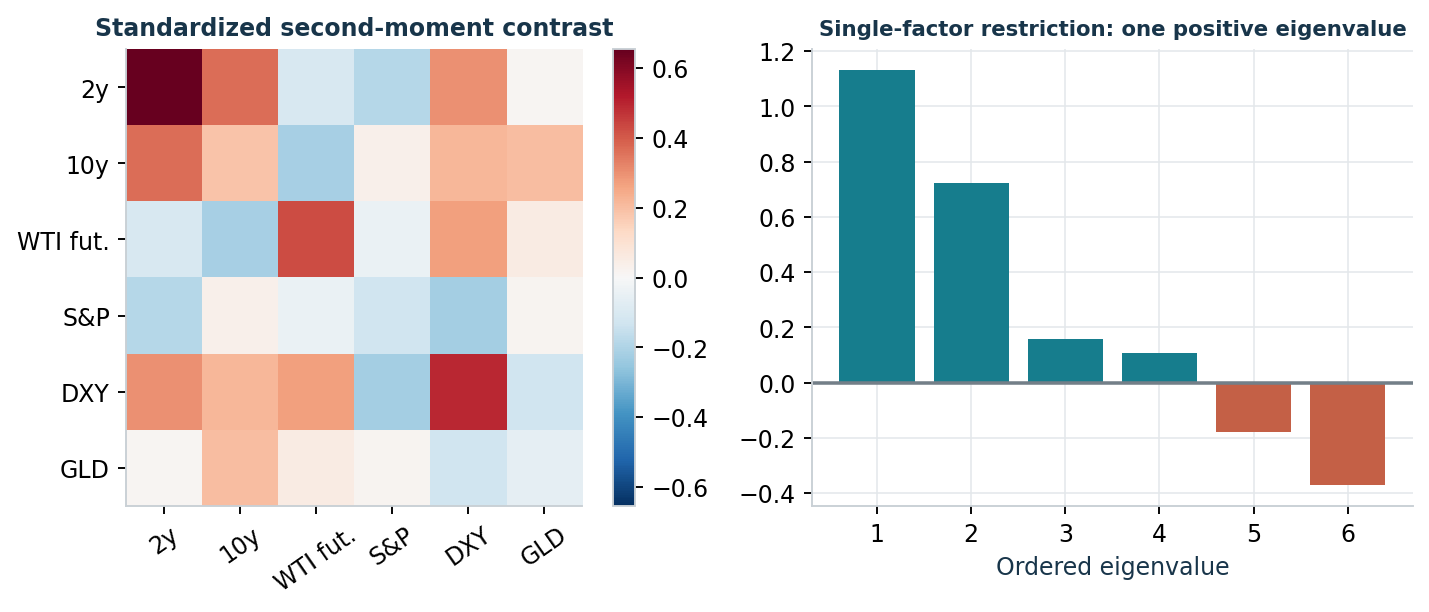

,specification,label,n_high,pooled_effect,weak_reference_variance_shift
0,CMT yields,10-year fitted Treasury,34,-0.1630,True
3,CMT yields,S&P 500,34,2.3066,True
9,CMT yields,WTI spot,34,16.6641,True
10,CMT yields,Brent spot,31,-5.1552,True
20,Curated event chronology,10-year fitted Treasury,18,-0.1576,True
23,Curated event chronology,S&P 500,18,2.9805,True
29,Curated event chronology,WTI spot,18,7.7352,True
30,Curated event chronology,Brent spot,14,6.8539,True
40,NLP quantile 0.667,10-year fitted Treasury,46,-0.1896,False
43,NLP quantile 0.667,S&P 500,46,2.8375,False


In [8]:
rank=json.loads((OUT/'paper_rank.json').read_text())
print('Eigenvalues:',np.round(rank['eigenvalues'],4),'Relative residual:',rank['rank_one_residual'])
display(Image(filename=str(OUT/'study_identification.png')))
robust=pd.read_csv(OUT/'paper_robustness.csv')
display(robust.loc[robust.variable.isin(['ten_year','sp500','wti_spot','brent_spot']),['specification','label','n_high','pooled_effect','weak_reference_variance_shift']])

## 9. Why the 2026 economy can produce a different table

The 2003 sample followed the dot-com collapse, September 11, accounting scandals and weak capital spending. It was a fragile recovery after the March–November 2001 recession. The [Federal Reserve’s February 2003 report](https://www.federalreserve.gov/boarddocs/hh/2003/february/ReportSection1.htm) records a 1.25% funds target and economic slack; [NBER’s chronology](https://www.nber.org/research/data/us-business-cycle-expansions-and-contractions) dates the recession. Demand weakness and safe-asset demand can explain falling yields, but the paper does not separately identify those channels.

Annual US crude production rises from **5.649 million barrels/day in 2003 to 13.662 in 2025**, or 141.8%; June 2026 is 13.792. Net imports of crude and petroleum products change from 11.238 million barrels/day in 2003 to net exports of 2.848 in 2025. Relative to products supplied, these are +56.1% and −13.7%. Crude-only net imports remain positive at 1.309 million barrels/day in June 2026. These are different trade concepts. [EIA production](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRFPUS2&f=A), [monthly production](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRFPUS2&f=M), [total net imports](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MTTNTUS2&f=A), [products supplied](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MTTUPUS2&f=A), [crude net imports](https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCRNTUS2&f=M).

A larger producer sector can offset some importing-firm and consumer losses, but US consumers still face global oil prices. Pre-conflict Hormuz flows were 20.9 million barrels/day in first-half **2025**, about 20% of global petroleum-liquids consumption; these are exposure figures, not 2026 traffic estimates. [EIA prices](https://www.eia.gov/energyexplained/oil-and-petroleum-products/prices-and-outlook.php); [chokepoints](https://www.eia.gov/international/content/analysis/special_topics/World_Oil_Transit_Chokepoints/).

January 2003 headline/core CPI inflation was 2.6%/1.9% year over year; August 2026 was 3.4%/2.4%, with energy up 16.3% and gasoline 27.4%. These observations motivate an inflation channel without attributing all inflation to war. [BLS 2003](https://www.bls.gov/news.release/archives/cpi_02212003.pdf); [BLS 2026](https://www.bls.gov/news.release/archives/cpi_09112026.htm). The BIS discusses energy-driven rate repricing and later real-term-premium pressures associated with fiscal concerns and issuance. Such channels can weaken the net flight-to-quality response, but these estimates do not isolate them. [BIS annual report](https://www.bis.org/publications/aer-2026/progress-peril); [September review](https://www.bis.org/publications/qr-202609/yields-climb-yet-risk-appetite-holds-firm).

On March 14, 2003, public CMT yields were 1.56% at two years and 3.72% at ten years, a 216-bp slope; September 17, 2026 has a 27-bp slope. [Historical H.15](https://www.federalreserve.gov/releases/h15/20030317/). The 2026 bear flattening can reflect expected short rates; ten-year yields also include inflation compensation and term/liquidity premia. The September 16 FOMC announcement at 14:00 ET raised the funds target 25 bp to 3.75–4.00%, effective September 17. CMT yields rose 7 bp at two years and 1 bp at ten years on announcement day, then fell 7 bp each the next day. Daily changes cannot isolate the announcement’s effect. [FOMC statement](https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a.htm); [implementation](https://www.federalreserve.gov/newsevents/pressreleases/monetary20260916a1.htm).

Differences from Iraq can therefore reflect supply exposure, inflation and financing conditions, expected war duration, news composition, instrument maturity and identification failure. Economic explanations do not validate an unstable coefficient automatically.

## 10. Good, bad and no-news states

The directional extension classifies **physical-event language** without observing returns. Continuing fighting/disruption is the “bad” category; cessation/reopening is “good.” These names concern conflict persistence, not political merit. A source reporting both belongs to mixed; attributed claims, negotiations without cessation and unclear reports remain separate. A declaration does not prove hostilities have stopped. Every eligible headline receives a category, including out-of-scope material.

The active window contains **39 continuation, 5 cessation, 4 no-retrieved-war-news, 12 mixed and 80 unclear/attributed sessions**. There is no universal zero-news state in the broad GDELT feed. The four publisher zeros are outlet-level absences and cannot establish fundamentals-only trading. Low intensity in the primary model includes ordinary war coverage and is different from no news.

The table reports conditional daily means, with actual observation counts. Continuation days average higher oil and ten-year yields and lower equities, as hypothesized. That association neither validates the text labels nor establishes causation: macroeconomic releases, reporting selection and prior market movements can coexist. Five cessation and four zero-news sessions provide too little support for a credible unrestricted three-state covariance model. Mixed and unclear days must not be forced into favorable or adverse classes.

A three-state IH extension would compare each active-news covariance with a shared low-news covariance, test common loadings, and resample shared controls jointly. Centered covariance would explicitly differ from the paper’s raw second moments, since directional states can have different means. More regimes help only with adequate counts and independent variance shifts. Rigobon’s order condition for three observed variables and one unrestricted common shock requires at least four regimes, plus a rank condition; three labels alone do not identify that system.

In [9]:
display(regimes.direction_regime.value_counts().rename('Sessions').to_frame())
direction=pd.read_csv(OUT/'directional_regime_markets.csv')
display(direction[['regime','sessions','outcome','observations','mean_change','median_change','sd_change','unit']])
assert regimes.high.eq(1).sum()==35 and regimes.high.eq(0).sum()==105
assert not regime_summary['selection_uses_market_returns']

,Sessions
direction_regime,
Direction unclear / attributed claims,80
Bad: continuation language,39
Mixed physical language,12
Good: cessation language,5
No retrieved war news,4


,regime,sessions,outcome,observations,mean_change,median_change,sd_change,unit
0,Bad: continuation language,39,two_year,39,0.0208,0.0200,0.0497,pp
1,Bad: continuation language,39,ten_year,39,0.0221,0.0200,0.0407,pp
2,Bad: continuation language,39,wti_spot,39,1.4024,2.2333,5.4516,%
3,Bad: continuation language,39,brent_spot,36,1.4599,1.4520,5.6196,%
4,Bad: continuation language,39,sp500,39,-0.1236,-0.0838,0.9217,%
5,Bad: continuation language,39,bbb_spread,36,0.0019,0.0000,0.0169,pp
6,Bad: continuation language,39,hy_spread,36,0.0053,0.0050,0.0725,pp
7,Bad: continuation language,39,gold_gld,39,-0.2593,0.0223,1.7482,%
8,Mixed physical language,12,two_year,11,-0.0045,-0.0200,0.0375,pp
9,Mixed physical language,12,ten_year,11,-0.0082,-0.0300,0.0405,pp


## 11. New war language and classification errors

A dictionary written for Iraq can miss Iranian facilities, Strait of Hormuz access, tanker disruption, drones and operation names. The audit compares a simple headline rule requiring Iran alongside war, conflict, fighting or military with an expanded rule covering relevant entities, physical action, shipping, energy, nuclear facilities, diplomacy and exact operation names. The comparator is an audit baseline, not a dictionary claimed to come from Rigobon and Sack or the primary body-text classifier.

Among 1,035 source documents, the comparator retrieves 244 and the expansion 642: **398 additional candidates**, with no comparator matches lost. More retrieval is not measured accuracy. Some additions concern background energy or nuclear issues; exact operation names can refer to earlier events. “New” here means newly retrieved relative to this comparator, not proof of newly coined wording.

The audit distinguishes extending a ceasefire, extending a deadline and extending a war. It flags negated ending/collapse language, conditional or modal wording, quotations, labor context and ambiguous grammatical targets. URLs are provenance, not classification text. There are 105 conditional/modal and 300 quotation cues; counts overlap and do not represent independent shocks.

Actual failures remain instructive. A headline describing Democrats renewing a push to curb the war can be attached incorrectly to war extension; stepping back from renewed conflict is not a fresh extension; a ceasefire-extension reference can concern Israel–Hezbollah rather than Iran. Nearest-target matching can also fail with multiple nouns, clause boundaries and unrelated negation. These documented errors preclude treating cues as verified duration news. Source-linked examples and all matched spans remain in the local audit.

The 17 constructed cases test software behavior; they do not estimate empirical precision, recall or probability calibration. Modern language models also face genuinely new phrases, misleading attribution and domain shift. A stronger evaluation would label a held-out, time-stratified sample independently, include mixed and uncertain classes, report class-specific precision/recall and agreement, and freeze the rule before future testing. No such independent accuracy estimate is claimed here.

In [10]:
print(json.dumps({k:phrase_summary[k] for k in ['distinct_source_documents','legacy_retrieved_documents','expanded_retrieved_documents','newly_retrieved_distinct_documents','accuracy_estimated','synthetic_software_checks']},indent=2))
display(pd.DataFrame(phrase_summary['cue_document_counts'].items(),columns=['Review cue','Documents']))
display(phrase_terms)
display(phrase_examples)
display(pd.read_csv(OUT/'phrase_audit_stress_cases.csv'))

{
  "distinct_source_documents": 1035,
  "legacy_retrieved_documents": 244,
  "expanded_retrieved_documents": 642,
  "newly_retrieved_distinct_documents": 398,
  "accuracy_estimated": false,
  "synthetic_software_checks": 17
}


,Review cue,Documents
0,code_name_cue,5
1,ceasefire_extension_cue,3
2,war_extension_cue,2
3,deadline_extension_cue,1
4,ceasefire_collapse_or_expiry_cue,4
5,negated_end_review,2
6,negated_collapse_review,0
7,conditional_or_modal_cue,105
8,quotation_cue,300
9,labor_context_cue,7


,rule_group,matched_term,distinct_documents,newly_retrieved_documents
0,ambiguous_common_term,deal,69,55
1,ambiguous_common_term,end,24,0
2,ambiguous_common_term,extend,1,1
3,ambiguous_common_term,extended,1,0
4,ambiguous_common_term,extends,2,2
...,...,...,...,...
91,shipping_access,strait,89,80
92,shipping_access,tanker,6,4
93,shipping_access,tankers,10,5
94,shipping_access,vessel,4,3


,example_type,data_origin,headline_snippet,source_url,published_utc,legacy_retrieved,expanded_retrieved,context_review_reasons,phrase_relations_json
0,newly_retrieved,observed cached publisher headline,Iran’s overtures of peace are at odds with its...,https://www.theguardian.com/world/2026/jan/08/...,2026-01-08T17:44:38.000Z,False,True,,[]
1,newly_retrieved,observed cached publisher headline,Iran warns US against attack as protest death ...,https://www.theguardian.com/world/2026/jan/11/...,2026-01-11T19:13:32.000Z,False,True,quotation or attribution,[]
2,code_name_cue,observed cached publisher headline,From ‘peace president’ to Operation Epic Fury:...,https://www.theguardian.com/us-news/2026/mar/0...,2026-03-07T09:00:46.000Z,False,True,quotation or attribution,[]
3,code_name_cue,observed cached publisher headline,‘Project Freedom’: a grand humanitarian gestur...,https://www.theguardian.com/us-news/2026/may/0...,2026-05-04T16:49:42.000Z,False,True,quotation or attribution; question rather than...,[]
4,ceasefire_extension_cue,observed cached publisher headline,Trump extends US-Iran ceasefire indefinitely a...,https://www.theguardian.com/world/2026/apr/21/...,2026-04-21T20:37:10.000Z,False,True,,"[{""action_kind"": ""extension"", ""action_word"": ""..."
5,ceasefire_extension_cue,observed cached publisher headline,Trump announces extension of Iran ceasefire un...,https://www.theguardian.com/world/2026/apr/21/...,2026-04-21T22:32:52.000Z,False,True,conditional/modal wording; quotation or attrib...,"[{""action_kind"": ""extension"", ""action_word"": ""..."
6,war_extension_cue,observed cached publisher headline,Democrats renew push to curb Trump’s Iran war ...,https://www.theguardian.com/us-news/2026/apr/0...,2026-04-08T18:23:42.000Z,True,True,,"[{""action_kind"": ""extension"", ""action_word"": ""..."
7,war_extension_cue,observed cached publisher headline,Israel and Iran step back from renewed conflic...,https://www.theguardian.com/world/2026/jun/08/...,2026-06-08T20:59:38.000Z,True,True,,"[{""action_kind"": ""extension"", ""action_word"": ""..."
8,deadline_extension_cue,observed cached publisher headline,Trump extends deadline for Iran to open strait...,https://www.theguardian.com/world/2026/mar/26/...,2026-03-27T05:41:44.000Z,False,True,,"[{""action_kind"": ""extension"", ""action_word"": ""..."
9,ceasefire_collapse_or_expiry_cue,observed cached publisher headline,"With the US-Iran ceasefire about to expire, co...",https://www.theguardian.com/world/2026/apr/21/...,2026-04-21T14:31:27.000Z,False,True,conditional/modal wording; question rather tha...,"[{""action_kind"": ""collapse_expiry"", ""action_wo..."


,case_id,data_origin,headline,source_url,expected_rule_outputs_json,actual_rule_outputs_json,software_check_passed,warning
0,S01,synthetic software stress test,Iran war continues,NaN,"{""legacy_retrieved"": true, ""war_continuation_c...","{""legacy_retrieved"": true, ""war_continuation_c...",True,Author-constructed examples; passing checks ar...
1,S02,synthetic software stress test,Tanker blocked in Strait of Hormuz,NaN,"{""expanded_retrieved"": true, ""legacy_retrieved...","{""expanded_retrieved"": true, ""legacy_retrieved...",True,Author-constructed examples; passing checks ar...
2,S03,synthetic software stress test,Operation Epic Fury enters a new phase,NaN,"{""code_name_cue"": true, ""expanded_retrieved"": ...","{""code_name_cue"": true, ""expanded_retrieved"": ...",True,Author-constructed examples; passing checks ar...
3,S04,synthetic software stress test,Iran ceasefire extended for two weeks,NaN,"{""ceasefire_extension_cue"": true, ""war_extensi...","{""ceasefire_extension_cue"": true, ""war_extensi...",True,Author-constructed examples; passing checks ar...
4,S05,synthetic software stress test,Iran war extended for another month,NaN,"{""ceasefire_extension_cue"": false, ""war_extens...","{""ceasefire_extension_cue"": false, ""war_extens...",True,Author-constructed examples; passing checks ar...
5,S06,synthetic software stress test,Iran ceasefire collapses after missile attack,NaN,"{""ceasefire_collapse_or_expiry_cue"": true}","{""ceasefire_collapse_or_expiry_cue"": true}",True,Author-constructed examples; passing checks ar...
6,S07,synthetic software stress test,Iran war is not over,NaN,"{""negated_end_review"": true, ""war_end_wording_...","{""negated_end_review"": true, ""war_end_wording_...",True,Author-constructed examples; passing checks ar...
7,S08,synthetic software stress test,"""Iran war could end if deal holds"", negotiator...",NaN,"{""attribution_cue"": true, ""conditional_or_moda...","{""attribution_cue"": true, ""conditional_or_moda...",True,Author-constructed examples; passing checks ar...
8,S09,synthetic software stress test,Tehran's workers plan a transport strike,NaN,"{""expanded_retrieved"": true, ""labor_context_cu...","{""expanded_retrieved"": true, ""labor_context_cu...",True,Author-constructed examples; passing checks ar...
9,S10,synthetic software stress test,Trade war with Iran escalates,NaN,"{""legacy_retrieved"": true, ""trade_war_cue"": true}","{""legacy_retrieved"": true, ""trade_war_cue"": true}",True,Author-constructed examples; passing checks ar...


## 12. Friday–Sunday news and market reaction windows

The reference clock is NYSE **09:30–16:00 New York time**, using the holiday calendar and daylight-saving conversion. An item maps to the first scheduled close strictly after its timestamp. Before-open and intraday news can enter the same session; news at or after the close enters the next. Friday after-close, Saturday and Sunday usually map to Monday, with holiday adjustments. A separate first-open clock and following reaction session are retained. [NYSE calendar](https://www.nyse.com/trade/hours-calendars).

The February 28 Saturday outbreak maps to March 2. The April 7 announcement at 18:32 ET maps to April 8; April 12 Sunday information maps to April 13. Known report times establish availability, not necessarily the first underlying event. Date-only curated events retain timing uncertainty. Their audit shows both the mapped session and the following session; the primary NLP model also receives a one-session timing sensitivity check.

The January-context publisher sample has **370 Friday–Sunday items**; Truth Social has **162**. The social set contains 128 market-open, 82 pre-open, 82 after-close, 101 weekend and 11 holiday records, including 15 Friday after-close posts. Publisher timing uses the later publication/modification time; social timing uses the original post clock. Neither necessarily identifies first public information, particularly for reposts.

Cash-equity closure is not closure of every market. WTI futures normally reopen Sunday at 18:00 ET; Treasury CMT quotes are indicative bids around 15:30 ET. Daily closing data cannot recover synchronized intraday responses or separate opening gaps from daytime moves. [CME WTI hours](https://www.cmegroup.com/education/courses/event-contracts-underlying-markets/wti-overview); [Treasury methodology](https://home.treasury.gov/policy-issues/financing-the-government/interest-rate-statistics).

GDELT bulk dates lack publisher timestamps. The conservative project clock is **07:00 ET the next calendar day**, followed by the next US close. One source URL is counted once per availability session but can recur on later days. The dynamic model consequently studies archive-availability associations. It cannot treat those files as a previous-day trading signal.

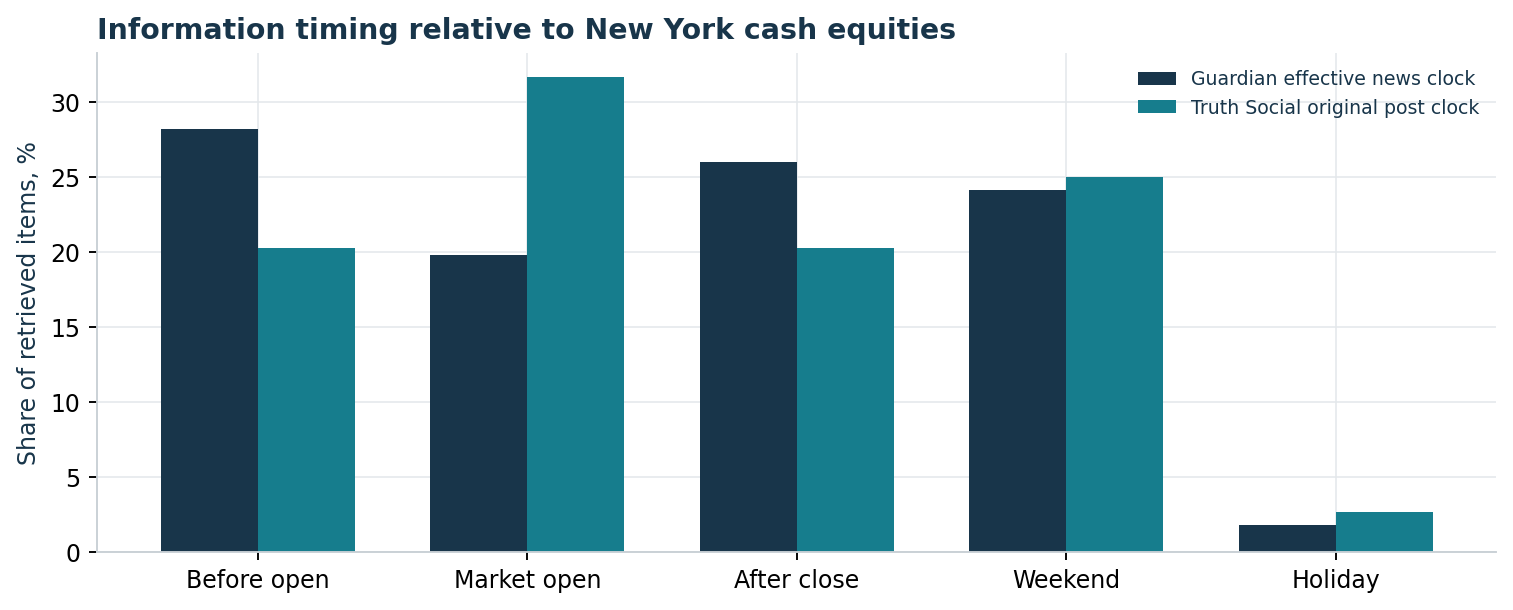

,event_date,cash_window,reaction_session,following_session,reaction_change,following_change,unit
2,2026-02-28,Weekend; closed,2026-03-02,2026-03-03,0.0398,-0.9444,%
14,2026-04-12,Weekend; closed,2026-04-13,2026-04-14,1.0173,1.1783,%
22,2026-04-17,Intraday time uncertain,2026-04-17,2026-04-20,1.2040,-0.2374,%
30,2026-05-03,Weekend; closed,2026-05-04,2026-05-05,-0.4062,0.8120,%
34,2026-06-07,Weekend; closed,2026-06-08,2026-06-09,0.2978,-0.2576,%
50,2026-06-28,Weekend; closed,2026-06-29,2026-06-30,1.1750,0.7920,%
70,2026-08-28,07:00 ET report; pre-open,2026-08-28,2026-08-31,-0.2487,-0.3322,%
74,2026-09-11,Intraday time uncertain,2026-09-11,2026-09-14,0.8599,-0.4832,%
78,2026-09-13,Weekend; closed,2026-09-14,2026-09-15,-0.4832,-0.4495,%


,event_date,outcome,reaction_session,following_session,reaction_change,following_change,unit
8,2026-04-07,wti_spot,2026-04-08,2026-04-09,-16.0674,3.5874,%
9,2026-04-07,brent_spot,2026-04-08,2026-04-09,-11.6489,-2.5223,%
10,2026-04-07,sp500,2026-04-08,2026-04-09,2.5081,0.6170,%
11,2026-04-07,ten_year,2026-04-08,2026-04-09,-0.0354,0.0007,pp


,Equity state,Posts
0,open,128
1,weekend,101
2,pre_open,82
3,after_close,82
4,holiday,11


In [11]:
display(Image(filename=str(OUT/'study_timing.png')))
reactions=pd.read_csv(OUT/'event_reaction_windows.csv')
display(reactions.loc[reactions.friday_sunday & reactions.outcome.eq('sp500'),['event_date','cash_window','reaction_session','following_session','reaction_change','following_change','unit']])
display(reactions.loc[reactions.event_date.eq('2026-04-07'),['event_date','outcome','reaction_session','following_session','reaction_change','following_change','unit']])
display(pd.DataFrame(social_summary['equity_state_counts'].items(),columns=['Equity state','Posts']))

## 13. Is heteroskedasticity identification the best approach?

**It is a useful benchmark, but this sample does not justify treating it as the best causal estimator.** Its advantage is that text needs only to identify greater war-shock variance, avoiding unreliable story-direction scores. Its demanding restrictions are stable transmission, unchanged nuisance moments, orthogonality and a sufficiently strong variance shift. Concurrent inflation, monetary-policy and energy-supply shocks make those restrictions difficult during an ongoing war. The rank and sensitivity diagnostics are material evidence against an unqualified one-factor interpretation.

The implemented alternative keeps two physical-news dimensions: cessation-coded and fighting-coded GDELT sources. Define $z_t^k=\Delta\log(1+N_t^k)/sd[\Delta\log(1+N_t^k)]$. Counts require an Iranian actor and an event dated zero to two days before archive entry. CAMEO 087 includes de-escalation/declarations; 19/20 cover fighting/violence. Both can occur in a mixed source. [CAMEO manual](https://data.gdeltproject.org/documentation/CAMEO.Manual.1.1b3.pdf). Scaling is retrospective, not a trading calibration.

For eight outcomes, local projections estimate cumulative responses from the preceding close through horizons 0, 1 and 5 sessions, beginning March 2. Controls include both news series and their lags, a lagged outcome, log calendar-interval length, month effects and FOMC dates. Price responses are cumulative simple percentages; yields and spreads use their stated difference units. HAC inference uses 5+h lags, finite-sample correction and t inference. Forty-eight primary coefficients form one Benjamini–Hochberg family; adjustment does not remove endogeneity.

**None of 48 primary coefficients has adjusted q below 0.05**; the smallest is **0.285**. This is limited evidence, not proof of no market effect. Sixteen separate prior-return checks use a lag-two outcome control to avoid regressing a variable on itself. **3 survive adjustment**: preceding WTI and Brent increases and a preceding S&P decline associated with fighting coverage. Movements before archive availability are consistent with earlier public news, common shocks or reporting following markets. These results cannot support a causal or immediately tradable news strategy.

A more suitable causal design would verify first-public timestamps and use narrow windows in synchronized Treasury, equity and matched-maturity oil futures. Separate unexpected cessation, supply interruption and renewed fighting; retain uncertainty; screen overlapping CPI/FOMC releases; distinguish Sunday futures from Monday cash trading. This improves timing but still requires clean windows and unanticipated information. Complete historical intraday quotes and reliable first-report clocks were not acquired, so this remains a proposal. [Federal Reserve announcement-window study](https://www.federalreserve.gov/pubs/ifdp/2006/886/ifdp886.htm).

External-instrument local projections could trace dynamics if a **signed surprise** were relevant to war risk and orthogonal to other shocks. The unsigned high-news indicator can change variance while having zero covariance with signed returns; it is not automatically that instrument. No validated external surprise is available here. [Stock and Watson (2018)](https://www.princeton.edu/~mwatson/papers/Stock_et_al-2018-The_Economic_Journal.pdf). Multi-regime IH is another feasible extension, conditional on sufficient counts, variance rank and stable loadings. These alternatives have different requirements; daily local projections alone do not solve causal identification.

A calibrated probability of termination would additionally require a fixed horizon, a verifiable termination definition, multiple conflicts or enough resolved episodes, and out-of-sample calibration. A single ongoing, right-censored conflict cannot supply that evidence by itself.

,outcome,feature,horizon,coefficient,se,p_value,q_value,n,unit,first_date,last_date
2,wti_spot,cessation,0,-0.0951,0.7100,0.8936,0.9701,137,%,2026-03-02,2026-09-15
3,wti_spot,fighting,0,1.2731,0.7237,0.0810,0.3536,137,%,2026-03-02,2026-09-15
4,wti_spot,cessation,1,-0.6510,0.7810,0.4062,0.8864,136,%,2026-03-02,2026-09-14
5,wti_spot,fighting,1,2.0033,0.9196,0.0313,0.2849,136,%,2026-03-02,2026-09-14
6,wti_spot,cessation,5,-0.3938,0.9443,0.6774,0.8864,132,%,2026-03-02,2026-09-08
7,wti_spot,fighting,5,3.7680,1.7727,0.0356,0.2849,132,%,2026-03-02,2026-09-08
10,brent_spot,cessation,0,-1.0655,0.7898,0.1800,0.6172,125,%,2026-03-02,2026-09-15
11,brent_spot,fighting,0,1.7456,0.9244,0.0616,0.3388,125,%,2026-03-02,2026-09-15
12,brent_spot,cessation,1,-1.7403,0.9206,0.0613,0.3388,124,%,2026-03-02,2026-09-14
13,brent_spot,fighting,1,2.4803,1.1433,0.0322,0.2849,124,%,2026-03-02,2026-09-14


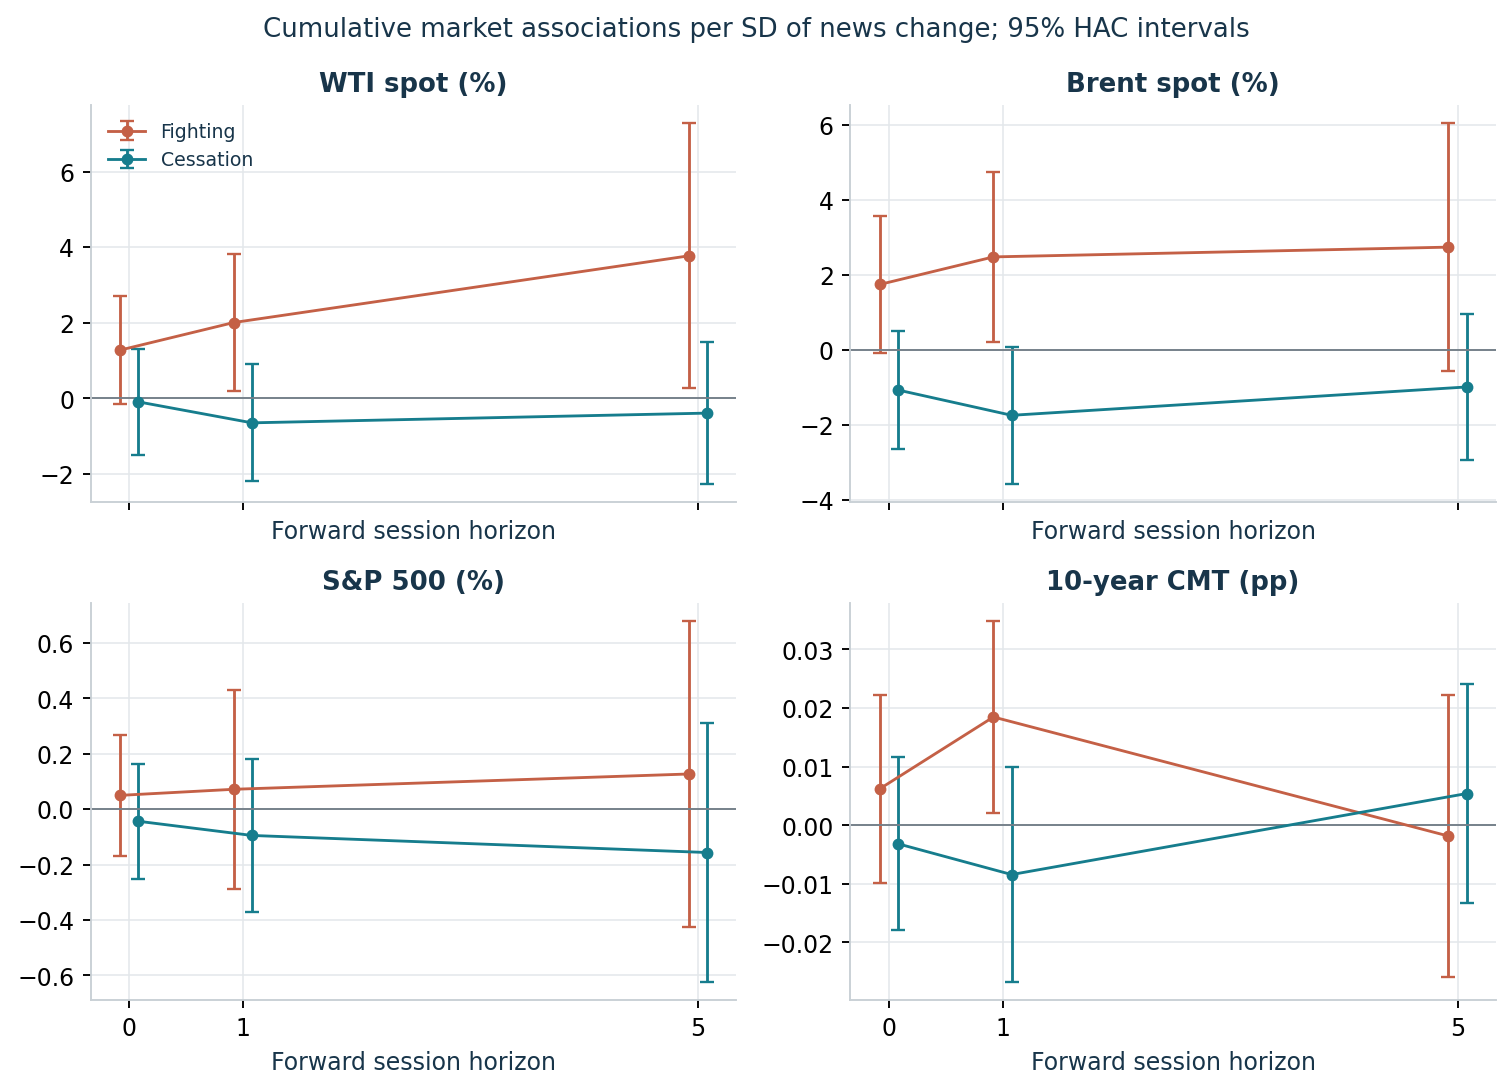

,outcome,feature,coefficient,p_value,q_value,n,unit
0,wti_spot,cessation,-1.7675,0.0371,0.0989,138,%
1,wti_spot,fighting,2.2140,0.0007,0.0110,138,%
8,brent_spot,cessation,-1.7333,0.0165,0.0527,123,%
9,brent_spot,fighting,2.3856,0.0041,0.0220,123,%
16,sp500,cessation,0.3091,0.0160,0.0527,140,%
17,sp500,fighting,-0.4082,0.0014,0.0110,140,%
24,two_year,cessation,0.0068,0.3175,0.4328,138,pp
25,two_year,fighting,-0.0093,0.1441,0.3294,138,pp
32,ten_year,cessation,-0.0062,0.2576,0.4122,138,pp
33,ten_year,fighting,-0.0012,0.8474,0.9971,138,pp


In [12]:
lp=pd.read_csv(OUT/'duration_local_projections.csv')
display(lp.loc[lp.horizon.ge(0),['outcome','feature','horizon','coefficient','se','p_value','q_value','n','unit','first_date','last_date']])
display(Image(filename=str(OUT/'study_alternative.png')))
display(lp.loc[lp.horizon.eq(-1),['outcome','feature','coefficient','p_value','q_value','n','unit']])
assert len(lp.loc[lp.horizon.ge(0)])==48
assert diagnostics['lp_primary_q_lt05']==0
assert diagnostics['lp_placebo_q_lt05']==3

## 14. Trump posts: platforms, sentiment and coverage

The public [CNN Truth Social archive](https://ix.cnn.io/data/truth-social/truth_archive.json) supplies original-post links and timestamps. The January 1–September 18 New York window contains **5,743 archive records**, including 1,908 with empty readable text. Literal Iran-related retrieval yields **404 candidates and 389 distinct text strings**. Every candidate ID, text and date is checked against the raw snapshot; nine selected IDs are independently corroborated through the American Presidency Project. No complete 2026 X/Twitter corpus was obtained. Platform coverage is explicit: the empirical corpus is Truth Social.

The candidate set includes 43 repost cues, four attribution-prefix cases, three URL-only records and 17 records containing media. Eleven match a keyword only inside a URL. Counts overlap and are not additive exclusions. Repeated text at different IDs remains a publication record. Untranscribed media, implicit references, linked content, deleted posts and source gaps prevent claiming all Iran-related Trump posts.

All candidates receive timing and nonexclusive literal subject flags after URL removal: 162 military/strike, 122 shipping/blockade, 111 negotiation/agreement, 85 nuclear, 63 energy-price and 15 ceasefire/truce records. These are corpus counts, not independent events, verified claims or numerical sentiment scores. Attack and negotiation language can coexist.

The sentiment analysis is qualitative and target-specific. Praise of a conversation evaluates the conversation; a conditional threat is not an observed attack; a claimed cancellation does not establish permanent peace. Interpretation preserves speaker, target, negation, tense, quoted/reposted content, emphasis and conditions. The linked readings illustrate these distinctions. No numerical evaluation of an official or policy, individual-post causal effect, or calibrated end-of-war probability is asserted. Full row-level timing and topic audits remain local; public outputs contain aggregates and selected examples.

In [13]:
audit=json.loads((OUT/'social_timing_summary.json').read_text())
display(pd.DataFrame(audit['equity_state_counts'].items(),columns=['Equity state','Records']))
print(json.dumps(audit,indent=2))
display(pd.read_csv(OUT/'social_monthly.csv'))
social_readings=[('2026-01-02', '115824439366264186', 'Conditional intervention tied to treatment of protesters. Future tense and the stated condition do not establish that intervention occurred.'), ('2026-01-12', '115884319075881590', 'A tariff announcement concerns trade restrictions, a separate channel from a physical interruption of crude supply.'), ('2026-02-04', '116013105630663812', 'Iran is one subject of a conversation with China’s president. Favorable language describes the conversation and relationship, rather than an observed end to conflict.'), ('2026-03-01', '116152251973821428', 'A conditional response to an anticipated Iranian action. Preserve the condition, future tense and emphasis when interpreting the statement.'), ('2026-04-01', '116329512466946656', 'A claimed ceasefire request, a Hormuz condition and continuing-attack language coexist. These propositions concern different outcomes and should be read separately.'), ('2026-05-03', '116512555123589170', 'A shipping-operation announcement appears alongside negotiation references. Navigation access and stated conditions matter for the oil-supply channel.'), ('2026-08-01', '117023461141824050', 'A claimed cancellation of a planned attack is linked to an agreement condition. It is not an unconditional statement that the conflict has ended.'), ('2026-09-01', '117196950497702512', 'The account reports strikes around Hormuz and states a condition for a further response. Keep the reported claim distinct from the prospective condition.'), ('2026-09-07', '117232304514057261', 'A forecast about oil and gasoline prices depends on a future war outcome. It is an attributed price claim, not an observed market effect.')]
social_examples=pd.DataFrame(social_readings,columns=['Date ET','Post ID','Contextual interpretation'])
social_examples['Original source']='https://truthsocial.com/@realDonaldTrump/'+social_examples['Post ID']
display(social_examples[['Date ET','Contextual interpretation','Original source']])

,Equity state,Records
0,open,128
1,weekend,101
2,pre_open,82
3,after_close,82
4,holiday,11


{
  "candidate_records": 404,
  "platform": "Truth Social",
  "publication_window_et": "2026-01-01 through 2026-09-18 inclusive",
  "input_sha256": {
    "data/processed/social_candidates.csv": "4611dc7fbb7ff4310a4e99dcb2836c1a66cdc85399baab97daad80ae0eae77eb",
    "outputs/social_relevance_audit.csv": "0df58cf15b4eb424dec66c7e5092b8cce7ede3089472cf0382e316e92ec1fc49",
    "data/processed/market_levels.csv": "e98be8e53ac605260a3600a398fc21c7084da265e51b81be974c1ceca7a2b85b"
  },
  "calendar_source": "https://www.nyse.com/trade/hours-calendars",
  "calendar_verified_date": "2026-09-19",
  "core_hours_et": "09:30 <= timestamp < 16:00; scheduled early closes use 13:00",
  "holidays_2026": {
    "2026-01-01": "New Year's Day",
    "2026-01-19": "Martin Luther King Jr. Day",
    "2026-02-16": "Washington's Birthday",
    "2026-04-03": "Good Friday",
    "2026-05-25": "Memorial Day",
    "2026-06-19": "Juneteenth",
    "2026-07-03": "Independence Day observed",
    "2026-09-07": "Labor Day",

,date_et,candidate_records
0,2026-01,11
1,2026-02,13
2,2026-03,78
3,2026-04,102
4,2026-05,38
5,2026-06,70
6,2026-07,26
7,2026-08,47
8,2026-09,19


,Date ET,Contextual interpretation,Original source
0,2026-01-02,Conditional intervention tied to treatment of ...,https://truthsocial.com/@realDonaldTrump/11582...
1,2026-01-12,A tariff announcement concerns trade restricti...,https://truthsocial.com/@realDonaldTrump/11588...
2,2026-02-04,Iran is one subject of a conversation with Chi...,https://truthsocial.com/@realDonaldTrump/11601...
3,2026-03-01,A conditional response to an anticipated Irani...,https://truthsocial.com/@realDonaldTrump/11615...
4,2026-04-01,"A claimed ceasefire request, a Hormuz conditio...",https://truthsocial.com/@realDonaldTrump/11632...
5,2026-05-03,A shipping-operation announcement appears alon...,https://truthsocial.com/@realDonaldTrump/11651...
6,2026-08-01,A claimed cancellation of a planned attack is ...,https://truthsocial.com/@realDonaldTrump/11702...
7,2026-09-01,The account reports strikes around Hormuz and ...,https://truthsocial.com/@realDonaldTrump/11719...
8,2026-09-07,A forecast about oil and gasoline prices depen...,https://truthsocial.com/@realDonaldTrump/11723...


## 15. Lessons from all seven local social-text readings

The seven supplied readings inform the social-text treatment below. Short posts require contextual reading: finance polarity, generic emotional valence and conflict persistence are different targets. No dictionary coefficient or predictive accuracy from those studies is transported into this corpus without validation. Reposts, negation, sarcasm, media and changing platform coverage remain explicit limitations.

In [14]:
reading_notes=[('Course presentation, undated', 'Twitter sentiment analysis overview', 'Keyword retrieval is a sampling rule; historical API instructions do not guarantee complete current archives.'), ('Yalin Yener, 2020', 'Step by Step: Twitter Sentiment Analysis in Python', 'Keep original text and a separate normalized field; distinguish reposts from duplicate IDs; vocabulary clouds do not validate sentiment.'), ('Bagheri and Islam, 2017', 'Sentiment analysis of twitter data', 'Short text, abbreviations and context challenge dictionary methods; query proportions are not accuracy estimates.'), ('Psomakelis et al., 2014', 'Comparing Methods for Twitter Sentiment Analysis', 'Representation and contextual features matter; their manually labeled benchmark does not establish accuracy on Iran-war statements.'), ('Carvalho and Plastino, 2021; online 2020', 'On the evaluation and combination of state-of-the-art features in Twitter sentiment analysis', 'Preserve negation and expressive features; evaluate feature combinations and domain transfer. Their binary benchmarks do not resolve neutral or mixed war text.'), ('Supplied presentation, undated', 'Exploring Differences in the Sentiment Analysis Tools using Twitter Data concerning Autism Awareness', 'Separate VADER from trained classifiers and use human validation. TN/(FP+TN) is specificity, not precision; VADER proportions are not probabilities.'), ('Stanford-derived course slides, undated', 'Sentiment Analysis', 'Identify the attitude holder, target and textual unit; irony and mixed targets make a generic positive/negative label unsuitable for war duration.')]
display(pd.DataFrame(reading_notes,columns=['Authors','Reference','Application']))

,Authors,Reference,Application
0,"Course presentation, undated",Twitter sentiment analysis overview,Keyword retrieval is a sampling rule; historic...
1,"Yalin Yener, 2020",Step by Step: Twitter Sentiment Analysis in Py...,Keep original text and a separate normalized f...
2,"Bagheri and Islam, 2017",Sentiment analysis of twitter data,"Short text, abbreviations and context challeng..."
3,"Psomakelis et al., 2014",Comparing Methods for Twitter Sentiment Analysis,Representation and contextual features matter;...
4,"Carvalho and Plastino, 2021; online 2020",On the evaluation and combination of state-of-...,Preserve negation and expressive features; eva...
5,"Supplied presentation, undated",Exploring Differences in the Sentiment Analysi...,Separate VADER from trained classifiers and us...
6,"Stanford-derived course slides, undated",Sentiment Analysis,"Identify the attitude holder, target and textu..."


## 16. Investment decision and reproducibility

The analysis supports monitoring oil-supply exposure and the yield curve, but **does not support a standalone leveraged directional trade based on this news signal**. Observed oil appreciation and equity gains are historical outcomes, not forecasts. The moment restrictions, unstable oil responses, source concentration and prior-return associations prevent treating the fitted coefficients as a reliable trading rule.

For a cash allocation awaiting stronger evidence, short Treasury bills are a transparent comparison asset; the September 15 three-month CMT observation of **4.11% annualized** is a dated indicative yield, not a guaranteed investment return. Decisions to hedge an existing energy exposure should depend on that exposure, costs and horizon. A Brent–WTI position additionally carries basis, maturity and execution risks; the physical spot spread is not itself a directly executable matched-contract trade.

The notebook recomputes the three tables, positive-yield scenario, nine sensitivity checks, directional comparisons, phrase audit, timing analysis and local projections from cached inputs. Source manifests record retrieval times, actual endpoints and SHA-256 hashes; source vintages remain local. Public code provides acquisition and analysis commands. Raw articles, post records, market datasets and derived datasets are excluded from Git; the executed notebook retains aggregate tables, figures and selected linked examples. The PDF is a separate submission artifact.

The strongest remaining limits are retrospective regime thresholds; one-outlet primary coverage; no independently labeled text evaluation; revisable publisher bodies and curve estimates; nonsynchronous daily markets; limited cessation/zero-news observations; multiple war and macroeconomic channels; and incomplete social-media coverage. The estimates are reproducible conditional measurements with these limits, rather than a verified probability that the war ends soon.

In [15]:
for name,digest in diagnostics['input_sha256'].items():
    assert hashlib.sha256((ROOT/name).read_bytes()).hexdigest()==digest,name
assert len(t1)==35
assert t2.available.sum()==19
assert int(t2.weak_reference_variance_shift.eq(True).sum())==2
print('Input hashes, table counts and scenario identities verified.')

Input hashes, table counts and scenario identities verified.
